# Scene Recognition by Combining Local and Global Image Descriptors


**Approach** : We make use of global feature descriptors as well as local feature descriptors simultaneously to represent each image, to improve recognition accuracy. Our basic steps are as follows

**1. Feature Extraction** : From each image, we first extract DAISY features [1] corresponding to the keypoints detected from the image. We make use of the skimage library (scikit-image) [2] for feature extraction. Corresponding to each keypoint in the image, there would be a DAISY descriptor with dimensions controlled by the parameters step size (distance between descriptor sampling points) and radius (describing size of the scanning area). We also extract a standard HOG descriptor corresponding to the entire image at a different granularity (by making use of the parameters pixels_per_cell, cells_per_block and orientations), effectively allowing us to choose features at different scales.


**2. Encoding** : We make use of the local DAISY features corresponding to each keypoints, to perform the encoding. We use the standard "bag-of-visual-words" concept here. Concretely, we apply K-means algorithm to quantize DAISY features into 'K' clusters to form "visual words". Thus, K becomes the size of our vocabulary. Corresponding to each image, we construct a histogram with 'K' as the dimensionality, based on this vocabulary.


**3. Pooling** : We make use of a 2-level pooling scheme. From the DAISY features, we construct a histogram by representing frequency of each visual word in each image. We do this by taking each key point in the image and looking up the cluster_id corresponding to that DAISY descriptor and incrementing the count corresponding to that bin in our histogram. This procedure is effectively a "sum pooling". We do an L2 normalization of the resulting histogram to form a "DAISY histogram feature". For the 2nd level pooling, we take the HOG global descriptor corresponding to each image and do an L2 normalization followed by a concatenation with the corresponding DAISY histogram feature.


**4. Classification** : We make use of the standard SVM classifier with various kernels. We utilize the sckit-learn (sklearn) library [3] for the SVM implementations. We do cross-validation by randomly splitting the dataset into a training and testing set. We construct the "visual vocabulary" as well as training feature vectors from the training split. We report the overall accuracy, confusion-matrix as well as standard information-retrieval statistics such as Precision, Recall and F-measure.




#### REFERENCES ########

[1] Tola, Engin, Vincent Lepetit, and Pascal Fua. "A fast local descriptor for dense matching." Computer Vision and Pattern Recognition, 2008. CVPR 2008. IEEE Conference on. IEEE, 2008.

[2] Van der Walt, Stefan, et al. "scikit-image: image processing in Python." PeerJ 2 (2014): e453.

[3] Pedregosa, Fabian, et al. "Scikit-learn: Machine learning in Python." Journal of Machine Learning Research 12.Oct (2011): 2825-2830.


In case if you find our code to be helpful, please consider citing our paper http://arxiv.org/abs/1702.06850. Wilson, J., Arif, M. (2017). Scene Recognition by Combining Local and Global Image Descriptors. arXiv preprint arXiv:1702.06850.

In [1]:
### import required libraries ###
### file/folder manipulation ###
from urllib.request import urlretrieve
from os import listdir
from os.path import isfile, join, exists
from zipfile import ZipFile
##for random split of dataset into a training set and a test set ###
from sklearn.model_selection import train_test_split
## image processing routines for feature extraction/transformation##
from skimage.feature import daisy,hog
from skimage import io
from skimage.color import rgb2gray
import skimage
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn import svm

from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
%matplotlib inline

#### Download Dataset

In [3]:
import os
import zipfile

zip_path = r"C:\Users\GOWTHAM\OneDrive\Desktop\VARUN\ChordShot\models\images\scene_categories (1).zip"
extract_path = r"C:\Users\GOWTHAM\OneDrive\Desktop\VARUN\ChordShot\models\images\scene_categories"

# Check if the folder already exists
if not os.path.exists(extract_path):
    print("Extracting scene_categories.zip...")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    print("Extraction complete!")
else:
    print("Dataset already extracted.")

Extracting scene_categories.zip...
Extraction complete!


#### Get all the filenames (including the full path) in a folder as a list.

In [4]:
import os

def get_filenames(path):
    """Returns a list of file paths in the given directory."""
    return [os.path.join(path, f) for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

In [7]:
file_list = get_filenames(r"C:\Users\GOWTHAM\OneDrive\Desktop\VARUN\ChordShot\models")
print(file_list)

['C:\\Users\\GOWTHAM\\OneDrive\\Desktop\\VARUN\\ChordShot\\models\\color_analysis.py', 'C:\\Users\\GOWTHAM\\OneDrive\\Desktop\\VARUN\\ChordShot\\models\\Object_detection.py', 'C:\\Users\\GOWTHAM\\OneDrive\\Desktop\\VARUN\\ChordShot\\models\\Scene_recognition.ipynb']


#### Function to extract daisy features as well as hog features from an image

In [ ]:

def extract_daisy_and_hog_features_from_image(
    file_path,
    daisy_step_size=32,
    daisy_radius=32,
    hog_pixels_per_cell=16,
    hog_cells_per_block=1
):
    """Extracts DAISY and HOG features from an image."""

    # Read the image
    img = io.imread(file_path)

    # Convert to grayscale only if it has 3 channels (RGB)
    if len(img.shape) == 3:
        img = rgb2gray(img)

    # Resize the image to a standard size
    img = skimage.transform.resize(img, (300, 250))

    # Extract DAISY features
    descs = daisy(
        img, step=daisy_step_size, radius=daisy_radius, rings=2,
        histograms=8, orientations=8, visualize=False
    )

    # Reshape DAISY descriptors
    descs_num = descs.shape[0] * descs.shape[1]
    daisy_descriptors = descs.reshape(descs_num, descs.shape[2])

    # Extract HOG features
    hog_descriptor = hog(
        img, orientations=8, pixels_per_cell=(hog_pixels_per_cell, hog_pixels_per_cell),
        cells_per_block=(hog_cells_per_block, hog_cells_per_block),
        visualize=False, feature_vector=True
    )

    return daisy_descriptors, hog_descriptor


In [9]:
from skimage.io import imread
def plot_file(fname):
    """Reads an image file and plots it in grayscale."""
    img_data = imread(fname)

    # Convert to grayscale only if the image has 3 channels (RGB)
    if len(img_data.shape) == 3:
        img_data = rgb2gray(img_data)

    plt.imshow(img_data, cmap='Greys_r')
    plt.axis("off")  # Hide axis for a cleaner look
    plt.show()

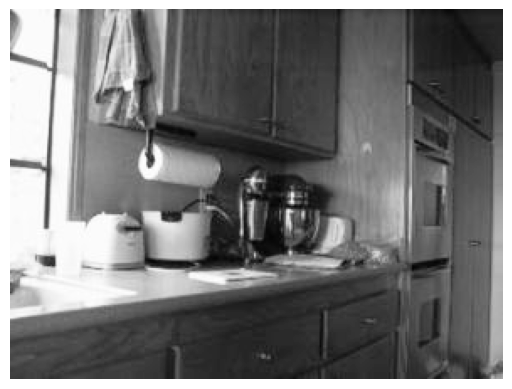

DAISY descriptor size: (1080, 136)
HOG descriptor size: (2160,)


In [11]:
base_path = r"C:\Users\GOWTHAM\OneDrive\Desktop\VARUN\ChordShot\models\images\scene_categories"

# Correct file path
fname = os.path.join(base_path, r"C:\Users\GOWTHAM\OneDrive\Desktop\VARUN\ChordShot\models\images\scene_categories\kitchen\image_0001.jpg")

# Plot the image (fixed function)
plot_file(fname)

# Extract DAISY and HOG features
daisy_sample, hog_sample = extract_daisy_and_hog_features_from_image(
    fname, daisy_step_size=8, daisy_radius=8
)

# Print feature descriptor sizes
print("DAISY descriptor size:", daisy_sample.shape)
print("HOG descriptor size:", hog_sample.shape)

In [12]:
img_width = 300
img_height = 250
hog_pixels_per_cell = 16
orientations = 8

print("HOG vector size =", (img_width // hog_pixels_per_cell) * (img_height // hog_pixels_per_cell) * orientations)


HOG vector size = 2160


#### Load file names corresponding to each scene category into lists

In [13]:
category_names = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
# Print category names with their assigned numeric labels
for i, category in enumerate(category_names):
    print(category, "=", i)

print("Total categories:", len(category_names))
# Initialize lists to store image file paths and labels
dataset_filenames = []
dataset_labels = []

# Loop through each category (folder)
for category in category_names:
    category_path = os.path.join(base_path, category)  # Correct path joining
    category_filenames = get_filenames(category_path)  # Get all file paths in that category

    # Assign a label (index of the category in category_names)
    category_labels = np.ones(len(category_filenames)) * category_names.index(category)
    category_labels = category_labels.astype(int)  # Convert labels to integers

    # Add filenames and labels to the dataset lists
    dataset_filenames.extend(category_filenames)
    dataset_labels.extend(category_labels)

bedroom = 0
CALsuburb = 1
industrial = 2
kitchen = 3
livingroom = 4
MITcoast = 5
MITforest = 6
MIThighway = 7
MITinsidecity = 8
MITmountain = 9
MITopencountry = 10
MITstreet = 11
MITtallbuilding = 12
PARoffice = 13
store = 14
Total categories: 15


In [14]:
print ("total dataset size:",len(dataset_filenames))

total dataset size: 4485


#### Split into training files and testing files

In [15]:
train_filenames,test_filenames,train_labels,test_labels=train_test_split(dataset_filenames,dataset_labels,test_size=0.6,random_state=42)
print ('total files in training split:',len(train_filenames))
print ('total files in testing split:',len(test_filenames))

total files in training split: 1794
total files in testing split: 2691


#### Extract features from training datasplit for downstream processing, takes aprox 12 mins for a standard laptop

In [16]:
training_data_feature_map={} ##map to store daisy feature as well as hog feature for all training datapoints
daisy_descriptor_list=[] ##list to store all daisy descriptors to form our visual vocabulary by clustering
counter=0
for fname in tqdm(train_filenames):
    daisy_features,hog_feature=extract_daisy_and_hog_features_from_image(fname,daisy_step_size=8,daisy_radius=8)
    ###extract DAISY features and HOG features from the image and save in a map###
    training_data_feature_map[fname]=[daisy_features,hog_feature]
    daisy_descriptor_list=daisy_descriptor_list+list(daisy_features)

100%|██████████| 1794/1794 [04:36<00:00,  6.49it/s]


In [17]:
print ("Total daisy descriptors:",len(daisy_descriptor_list))

Total daisy descriptors: 1937520


#### Now to form "visual-words", we cluster DAISY features to form a vocabulary, we form a histogram feature (daisy histogram) corresponding to each feature of 'number_of_clusters' dimensions
input: list of DAISY features and number of clusters

output: a trained cluster model which will allow to get the cluster id corresponding to any input daisy feature

In [18]:
def cluster_daisy_features(daisy_feature_list, number_of_clusters):
    """Clusters DAISY feature descriptors using MiniBatchKMeans."""
    km = MiniBatchKMeans(n_clusters=number_of_clusters, batch_size=number_of_clusters * 10, random_state=42)
    km.fit(daisy_feature_list)
    return km

In [19]:
### hide warnings ##
import warnings
warnings.filterwarnings('ignore')

#### Number of clusters is set as 600#,takes aprox 10 mins to run on standard laptop

In [20]:
daisy_cluster_model=cluster_daisy_features(daisy_descriptor_list,600)
daisy_cluster_model.n_clusters

600

#### Function to extract hybrid feature from images by pooling daisy histogram and hog descriptor after individual

In [21]:
def extract_daisy_hog_hybrid_feature_from_image(fname,daisy_cluster_model):
    #incase if we have encountered the file during training, the daisy and hog features would already have been computed
    if fname in training_data_feature_map:
        daisy_features=training_data_feature_map[fname][0]
        hog_feature=training_data_feature_map[fname][1]
    else:
        daisy_features,hog_feature=extract_daisy_and_hog_features_from_image(fname,daisy_step_size=8,daisy_radius=8)

    ##find to which clusters each daisy feature belongs
    img_clusters=daisy_cluster_model.predict(daisy_features)
    cluster_freq_counts=pd.DataFrame(img_clusters,columns=['cnt'])['cnt'].value_counts()
    bovw_vector=np.zeros(daisy_cluster_model.n_clusters) ##feature vector of size as the total number of clusters
    for key in cluster_freq_counts.keys():
        bovw_vector[key]=cluster_freq_counts[key]

    bovw_feature=bovw_vector/np.linalg.norm(bovw_vector)
    hog_feature=hog_feature/np.linalg.norm(hog_feature)
    return list(bovw_feature)+list(hog_feature)

#### Training data feature extraction

In [22]:
XTRAIN=[]
YTRAIN=[]
for i in tqdm(range(len(train_filenames))):
    XTRAIN.append(extract_daisy_hog_hybrid_feature_from_image(train_filenames[i],daisy_cluster_model))
    YTRAIN.append(train_labels[i])

100%|██████████| 1794/1794 [00:21<00:00, 85.28it/s] 


#### Train an SVM classifier and get accuracy report

In [23]:
hybrid_classifier=svm.SVC(C=10**1.6794140624999994, gamma=10**-0.1630955304365928, decision_function_shape='ovo') #cross-validated hyper-parameters
hybrid_classifier.fit(XTRAIN,YTRAIN)

SVC(C=47.798477392518556, decision_function_shape='ovo',
    gamma=0.6869173242795459)

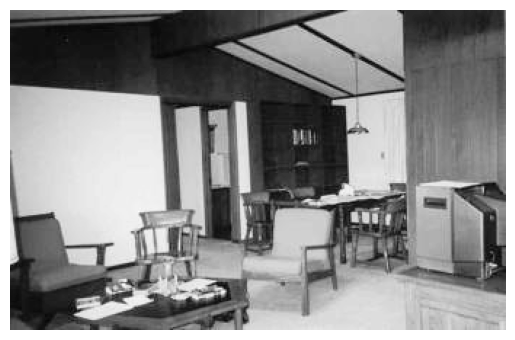

true label: 4
prediction: [4]


In [24]:
### show a sample classification ###
plot_file(test_filenames[3])
print ("true label:",test_labels[3])
hybrid_feature_vector=extract_daisy_hog_hybrid_feature_from_image(test_filenames[3],daisy_cluster_model)
print ("prediction:",hybrid_classifier.predict([hybrid_feature_vector]))

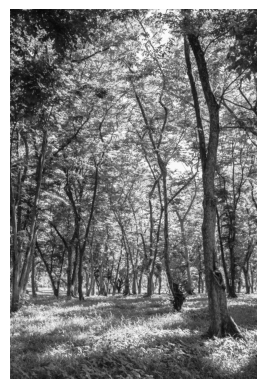

Prediction: [6]


In [26]:
### show a sample classification on external file ###
external_file_name=r"C:\Users\GOWTHAM\OneDrive\Desktop\VARUN\ChordShot\images\de86842782501f14cef6639d57b3312b.jpg"
plot_file(external_file_name)
hybrid_feature_vector=extract_daisy_hog_hybrid_feature_from_image(external_file_name,daisy_cluster_model)
print ("Prediction:",hybrid_classifier.predict([hybrid_feature_vector]))

In [27]:
import joblib

# Save the trained classifier
joblib.dump(hybrid_classifier, "hybrid_classifier.pkl")

print("Model saved successfully as hybrid_classifier.pkl")


Model saved successfully as hybrid_classifier.pkl


In [28]:
# Load the saved model
hybrid_classifier = joblib.load("hybrid_classifier.pkl")

print("Model loaded successfully")

Model loaded successfully


In [30]:
import joblib

# Load the saved classifier
hybrid_classifier = joblib.load("hybrid_classifier.pkl")

# Verify it still works
external_file_name = r"C:\Users\GOWTHAM\OneDrive\Desktop\VARUN\ChordShot\images\de86842782501f14cef6639d57b3312b.jpg"

# Extract features again
hybrid_feature_vector = extract_daisy_hog_hybrid_feature_from_image(external_file_name, daisy_cluster_model)

# Define category mapping
category_mapping = {
    0: "bedroom",
    1: "CALsuburb",
    2: "industrial",
    3: "kitchen",
    4: "livingroom",
    5: "MITcoast",
    6: "MITforest",
    7: "MIThighway",
    8: "MITinsidecity",
    9: "MITmountain",
    10: "MITopencountry",
    11: "MITstreet",
    12: "MITtallbuilding",
    13: "PARoffice",
    14: "store"
}

# Get model prediction
predicted_index = hybrid_classifier.predict([hybrid_feature_vector])[0]  # Extract the integer index

# Convert index to category name
predicted_category = category_mapping[predicted_index]

print("Prediction:", predicted_category)



Prediction: MITforest


In [31]:
joblib.dump(daisy_cluster_model, "daisy_cluster_model.pkl")

['daisy_cluster_model.pkl']